# Actividad 1 - Regresión Lineal

### En esta actividad se trabaja con un dataset construido a partir de información publicada por el Observatorio de COFA sobre el consumo de psicofármacos en Argentina.

### El objetivo es predecir el consumo total mensual de psicofármacos a partir delconsumo de distintos tipos de medicamentos:

* ### Ansiolíticos
* ### Antidepresivos
* ### Antipsicóticos
* ### Hipnóticos

### Se trata de un problema de regresión, ya que la variable objetivo (total_consumo) es continua.

## IMPORTACION DE LIBRERIAS

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## CARGA Y EXPLORACION DE DATOS

### Se carga el dataset y se analiza su estructura.

In [23]:
df = pd.read_csv("psicofarmacos_argentina.csv")

df.head()

,anio,mes,ansioliticos,antidepresivos,antipsicoticos,hipnoticos,total_consumo
0,2023,1,120,95,40,60,315
1,2023,2,125,98,42,62,327
2,2023,3,130,102,43,65,340
3,2023,4,128,100,45,63,336
4,2023,5,135,105,46,68,354


In [24]:
df['fecha'] = pd.to_datetime(df['anio'].astype(str) + '-' + 
                             df['mes'].astype(str) + '-01')

df = df.sort_values('fecha').reset_index(drop=True)

df.head()

,anio,mes,ansioliticos,antidepresivos,antipsicoticos,hipnoticos,total_consumo,fecha
0,2023,1,120,95,40,60,315,2023-01-01
1,2023,2,125,98,42,62,327,2023-02-01
2,2023,3,130,102,43,65,340,2023-03-01
3,2023,4,128,100,45,63,336,2023-04-01
4,2023,5,135,105,46,68,354,2023-05-01


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   anio            18 non-null     int64         
 1   mes             18 non-null     int64         
 2   ansioliticos    18 non-null     int64         
 3   antidepresivos  18 non-null     int64         
 4   antipsicoticos  18 non-null     int64         
 5   hipnoticos      18 non-null     int64         
 6   total_consumo   18 non-null     int64         
 7   fecha           18 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(7)
memory usage: 1.3 KB


In [26]:
df.describe()

,anio,mes,ansioliticos,antidepresivos,antipsicoticos,hipnoticos,total_consumo,fecha
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18
mean,2023.333333,5.500000,154.388889,125.055556,53.888889,77.111111,410.444444,2023-09-15 22:40:00
min,2023.000000,1.000000,120.000000,95.000000,40.000000,60.000000,315.000000,2023-01-01 00:00:00
25%,2023.000000,3.000000,136.250000,106.250000,46.500000,68.500000,357.500000,2023-05-08 18:00:00
50%,2023.000000,5.000000,152.500000,122.500000,52.500000,76.500000,404.000000,2023-09-16 00:00:00
75%,2024.000000,7.750000,173.750000,143.750000,61.500000,87.250000,466.250000,2024-01-24 06:00:00
max,2024.000000,12.000000,190.000000,160.000000,70.000000,95.000000,515.000000,2024-06-01 00:00:00
std,0.485071,3.399827,22.096417,21.158984,9.164438,11.124371,63.488973,NaN


## Visualización de datos

### Se observa la relación entre algunas variables.

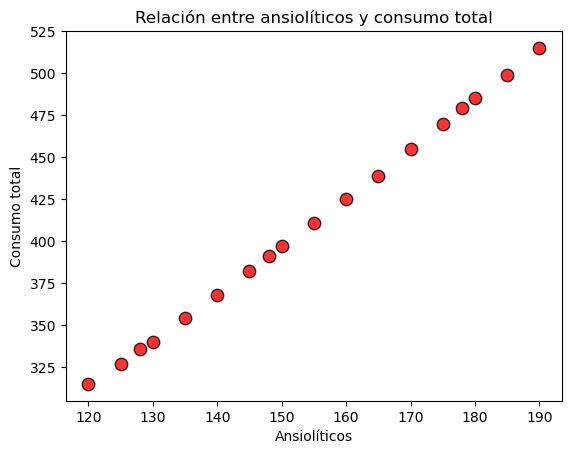

In [27]:
plt.scatter(df['ansioliticos'], df['total_consumo'],color='red',s=80,alpha=0.8,edgecolor='black')
plt.xlabel("Ansiolíticos")
plt.ylabel("Consumo total")
plt.title("Relación entre ansiolíticos y consumo total")
plt.show()

## Preparación de los datos

### Se definen las variables predictoras y la variable objetivo.
Luego se divide el dataset en entrenamiento y prueba.

In [21]:
X = df[['ansioliticos', 'antidepresivos', 'antipsicoticos', 'hipnoticos']]
y = df['total_consumo']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Entrenamiento del modelo

### Se utiliza regresión lineal para ajustar el modelo.

In [29]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Evaluación del modelo

### Se evalúa el desempeño mediante métricas de regresión.

In [17]:
y_pred = modelo.predict(X_test)

print("Error absoluto medio:", mean_absolute_error(y_test, y_pred))
print("Error cuadrático medio:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Error absoluto medio: 2.842170943040401e-14
Error cuadrático medio: 1.6155871338926322e-27
R2: 1.0


## Comparación entre valores reales y predichos

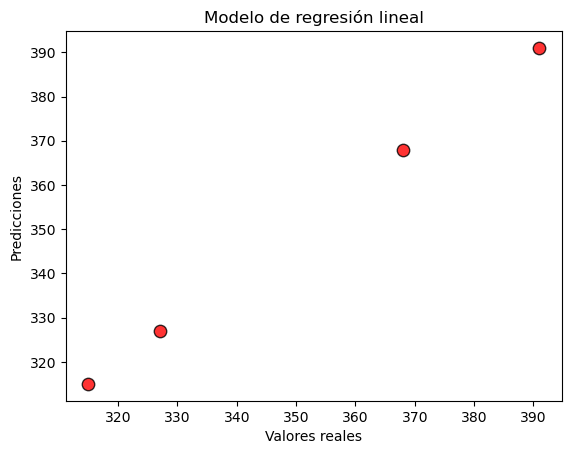

In [30]:
plt.scatter(y_test, y_pred,color='red',s=80,alpha=0.8,edgecolor='black')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Modelo de regresión lineal")
plt.show()

## Predicción de un nuevo caso

### Se utiliza el modelo para estimar el consumo total a partir de nuevos valores.

In [32]:
nuevo = pd.DataFrame({
    'ansioliticos': [200],
    'antidepresivos': [160],
    'antipsicoticos': [70],
    'hipnoticos': [95]
})

prediccion = modelo.predict(nuevo)

print("Consumo total estimado:", prediccion[0])

Consumo total estimado: 525.0


## CONCLUSION 

### El modelo de regresión lineal permitió predecir el consumo total de psicofármacos a partir de distintos tipos de medicamentos.

### Se observa una fuerte relación entre las variables, ya que el consumo total está directamente compuesto por ellas.

### El modelo presenta un buen ajuste, lo cual se refleja en las métricas obtenidas.

### Además, esta actividad permite analizar una problemática relevante en Argentina, como es el aumento del consumo de psicofármacos, mostrando cómo el análisis de datos puede contribuir a comprender fenómenos sociales y de salud.

### La actividad resultó accesible en términos de implementación, aunque requirió comprender el proceso de preparación de datos y evaluación del modelo.

# IMPORTANTE
## Construcción del dataset

### Para la realización de esta actividad se buscó trabajar con datos reales vinculados al consumo de psicofármacos en Argentina, ya que es un tema de interés en relación a la salud mental.

### Sin embargo, durante la búsqueda de información se observó que no existen datasets abiertos en formato CSV directamente disponibles sobre este tema específico. En su lugar, los datos se encuentran publicados en informes, artículos y visualizaciones (gráficos), lo que dificulta su uso directo en herramientas de análisis de datos.

### Por este motivo, se procedió a construir un dataset propio a partir de la información presentada en dichos informes. Para ello, se tomaron como referencia valores agregados sobre el consumo de distintos tipos de psicofármacos (ansiolíticos, antidepresivos, antipsicóticos e hipnóticos) y se organizaron en una estructura tabular mensual.

### El dataset generado incluye:
* ### Variables independientes: consumo por tipo de psicofármaco
* ### Variable dependiente: consumo total mensual

### Este proceso de construcción implicó una tarea de sistematización y adaptación de los datos, lo cual forma parte del trabajo habitual en análisis de datos cuando la información no se encuentra disponible en formato estructurado.

### Si bien el dataset no proviene de una descarga directa en formato CSV, se basa en datos reales y tendencias observadas en informes oficiales, por lo que permite realizar un análisis válido desde el punto de vista metodológico.

# FUENTES  

* ## Informe del Observatorio de la Confederación Farmacéutica Argentina (COFA):
  https://observatorio.cofa.org.ar/index.php/2025/06/27/consumo-de-psicofarmacos-en-argentina/

* ## Observatorio Argentino de Drogas (SEDRONAR):
  https://www.argentina.gob.ar/sedronar/observatorio-argentino-de-drogas

* ## Encuesta Nacional sobre Consumos y Prácticas de Cuidado (ENCoPraC):
  https://www.argentina.gob.ar/sedronar/observatorio-argentino-de-drogas/encuesta-nacional-sobre-consumos-y-practicas-de-cuidado-0